In [16]:
import sys
import os
from pathlib import Path

# Agregar src al path para importar módulos del proyecto
project_root = Path("..").resolve()
sys.path.append(str(project_root / "src"))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json

from forecast_income.utils.config import load_config
from forecast_income.features.feature_engineering import FeatureConfig, create_features

# Configuración de estilos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("✅ Librerías importadas y entorno configurado.")

✅ Librerías importadas y entorno configurado.


## 1. Carga de Datos (Master Table)

Cargamos la tabla maestra generada por el comando `python -m src.cli build-master`. Esta tabla contiene los datos históricos mensuales limpios.

In [17]:
# Cargar configuración
params = load_config("../config/params.yaml")

# Cargar Master Table
master_path = project_root / params["data"]["master_table_path"]
df_master = pd.read_csv(master_path, parse_dates=[params["data"]["index_col"]])
df_master = df_master.sort_values("month").reset_index(drop=True)

print(f"📅 Rango de fechas: {df_master['month'].min().date()} a {df_master['month'].max().date()}")
print(f"📊 Dimensiones: {df_master.shape}")
df_master.tail()

📅 Rango de fechas: 2016-09-01 a 2018-08-01
📊 Dimensiones: (23, 13)


,month,monthly_revenue,total_orders,avg_review_score,active_days,total_items,total_freight,unique_customers,avg_installments,top_category,new_sellers,year,month_num
18,2018-04-01,1160785.48,6939,4.162502,30,7975.0,163050.29,6882,2.741159,cama_mesa_banho,202,2018,4
19,2018-05-01,1153982.15,6873,4.194034,31,7925.0,153264.14,6814,2.875261,beleza_saude,172,2018,5
20,2018-06-01,1023880.50,6167,4.277479,30,7078.0,157552.80,6128,2.864818,beleza_saude,191,2018,6
21,2018-07-01,1066540.75,6292,4.263246,31,7092.0,163220.81,6230,2.746345,beleza_saude,190,2018,7
22,2018-08-01,1022425.32,6512,4.256207,31,7248.0,148622.14,6460,2.763243,beleza_saude,155,2018,8


## 2. Ingeniería de Características y Matriz de Correlación

El modelo no usa los datos crudos. Generamos variables sintéticas (Lags, Rolling Windows) para capturar tendencias temporales.

A continuación, generamos todas las features posibles (95+) y analizamos su correlación con el objetivo (`monthly_revenue` del mes siguiente).

In [18]:
# Configuración de Features
cfg = FeatureConfig(
    base_cols=params["features"]["base_cols"],
    lags=params["features"]["lags"],
    rolling_windows=params["features"]["rolling_windows"],
    add_seasonality=params["features"]["add_seasonality"],
    add_trend=params["features"]["add_trend"],
    target_col=params["features"]["target_col"],
)

# Generar Features
df_features, feature_names = create_features(df_master, cfg, date_col="month")

# Crear el Target (Revenue del mes siguiente) para análisis de correlación
df_features["target_next_month"] = df_features["monthly_revenue"].shift(-1)

# Filtrar filas sin target (último mes) para la correlación
df_corr_analysis = df_features.dropna(subset=["target_next_month"])

# Seleccionar solo columnas numéricas para evitar errores con columnas de texto
df_corr_numeric = df_corr_analysis.select_dtypes(include=[np.number])

# Calcular correlación de todas las features con el target
correlations = df_corr_numeric.corr()["target_next_month"].drop("target_next_month").sort_values(ascending=False)

print("🔝 Top 10 Features con mayor correlación positiva:")
print(correlations.head(10))
print("\n🔻 Top 10 Features con mayor correlación negativa:")
print(correlations.tail(10))

🔝 Top 10 Features con mayor correlación positiva:
total_orders_lag_1             0.940548
monthly_revenue_lag_1          0.939711
unique_customers_lag_1         0.939628
total_items_lag_1              0.939048
monthly_revenue_roll_max_6     0.937220
monthly_revenue_roll_max_3     0.936708
total_orders_roll_max_3        0.933393
unique_customers_roll_max_3    0.932615
total_items_roll_max_3         0.932503
total_freight_lag_1            0.932329
Name: target_next_month, dtype: float64

🔻 Top 10 Features con mayor correlación negativa:
total_freight_pct_change      -0.176612
total_items_pct_change        -0.183285
avg_installments_pct_change   -0.190014
total_orders_pct_change       -0.196034
unique_customers_pct_change   -0.197240
avg_review_score_pct_change   -0.368967
avg_review_score_roll_std_3   -0.670192
avg_installments_roll_std_3   -0.734820
avg_review_score_roll_std_6   -0.818075
avg_installments_roll_std_6   -0.891165
Name: target_next_month, dtype: float64


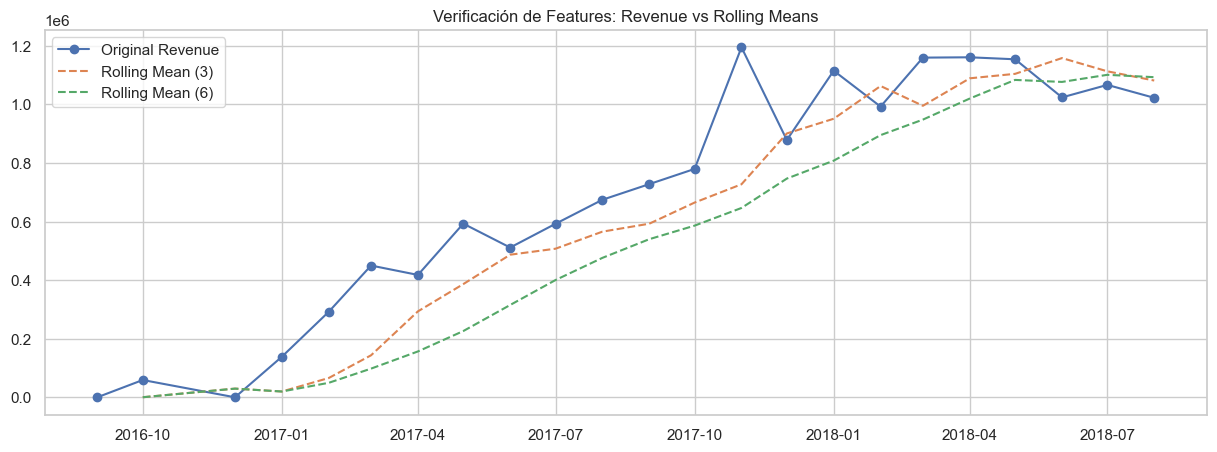

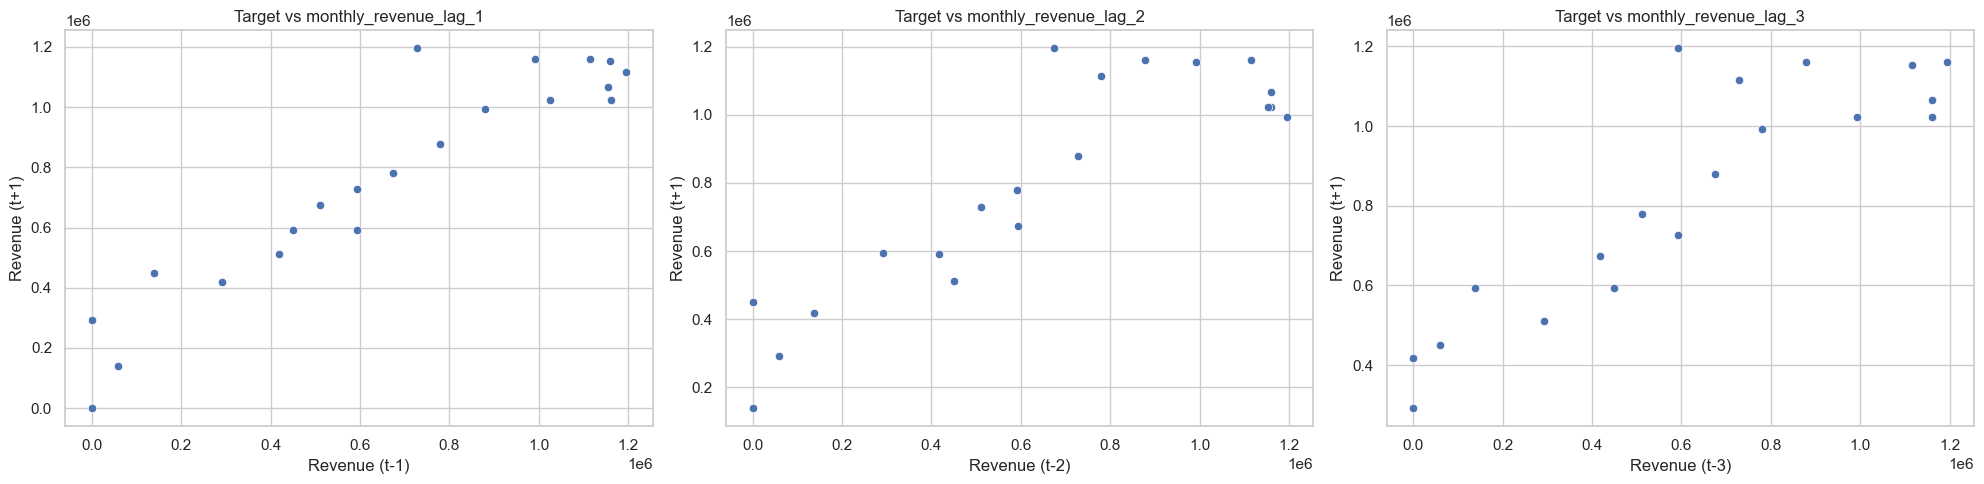

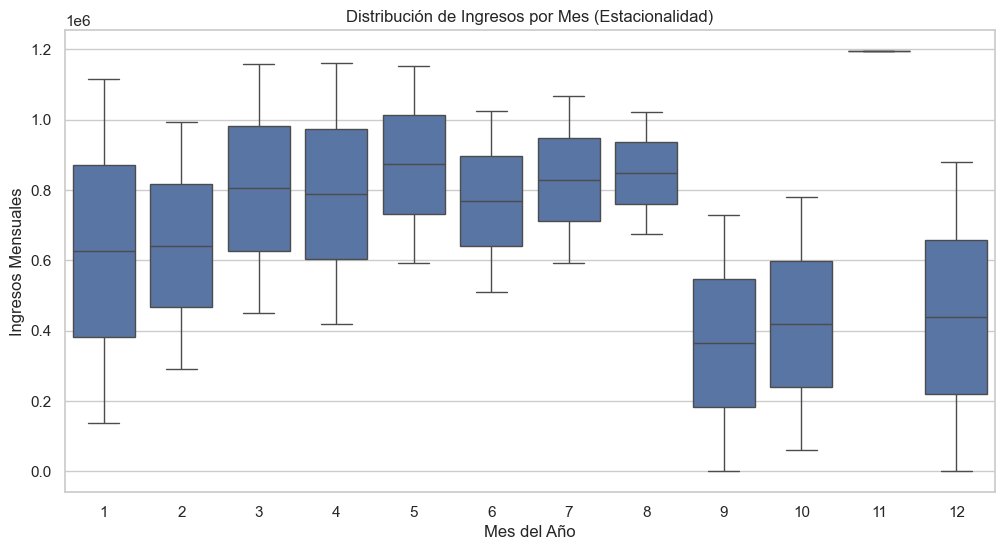

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15, 10)

# 1. Visualización de Rolling Means vs Original
plt.figure(figsize=(15, 5))
plt.plot(df_features["month"], df_features["monthly_revenue"], label="Original Revenue", marker="o")
if "monthly_revenue_roll_mean_3" in df_features.columns:
    plt.plot(df_features["month"], df_features["monthly_revenue_roll_mean_3"], label="Rolling Mean (3)", linestyle="--")
if "monthly_revenue_roll_mean_6" in df_features.columns:
    plt.plot(df_features["month"], df_features["monthly_revenue_roll_mean_6"], label="Rolling Mean (6)", linestyle="--")
plt.title("Verificación de Features: Revenue vs Rolling Means")
plt.legend()
plt.show()

# 2. Visualización de Lags (Scatter Plots)
lags_to_plot = [1, 2, 3, 12]
cols = [f"monthly_revenue_lag_{lag}" for lag in lags_to_plot if f"monthly_revenue_lag_{lag}" in df_features.columns]

if cols:
    fig, axes = plt.subplots(1, len(cols), figsize=(20, 5))
    for i, col in enumerate(cols):
        sns.scatterplot(data=df_features, x=col, y="target_next_month", ax=axes[i])
        axes[i].set_title(f"Target vs {col}")
        axes[i].set_xlabel(f"Revenue (t-{lags_to_plot[i]})")
        axes[i].set_ylabel("Revenue (t+1)")
    plt.tight_layout()
    plt.show()

# 3. Visualización de Estacionalidad (Boxplot por mes)
if "month_num" in df_features.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_features, x="month_num", y="monthly_revenue")
    plt.title("Distribución de Ingresos por Mes (Estacionalidad)")
    plt.xlabel("Mes del Año")
    plt.ylabel("Ingresos Mensuales")
    plt.show()

### Análisis Visual de Ingeniería de Características
Antes de pasar a la selección, verificamos visualmente que las features generadas tengan sentido.
1. **Rolling Windows**: Comparamos la serie original con sus medias móviles.
2. **Lags**: Vemos la relación lineal entre el mes actual y los meses anteriores.
3. **Estacionalidad**: Analizamos la distribución de ingresos por mes del año.

### Visualización: Matriz de Correlación

Seleccionamos las 15 variables más importantes para visualizar cómo se relacionan entre sí y con el objetivo. Esto justifica por qué el modelo selecciona ciertas variables y descarta otras (multicolinealidad).

📉 Total features iniciales: 105
✂️ Eliminando 81 features con correlación > 0.90 (Redundantes)...
✅ Features restantes: 24


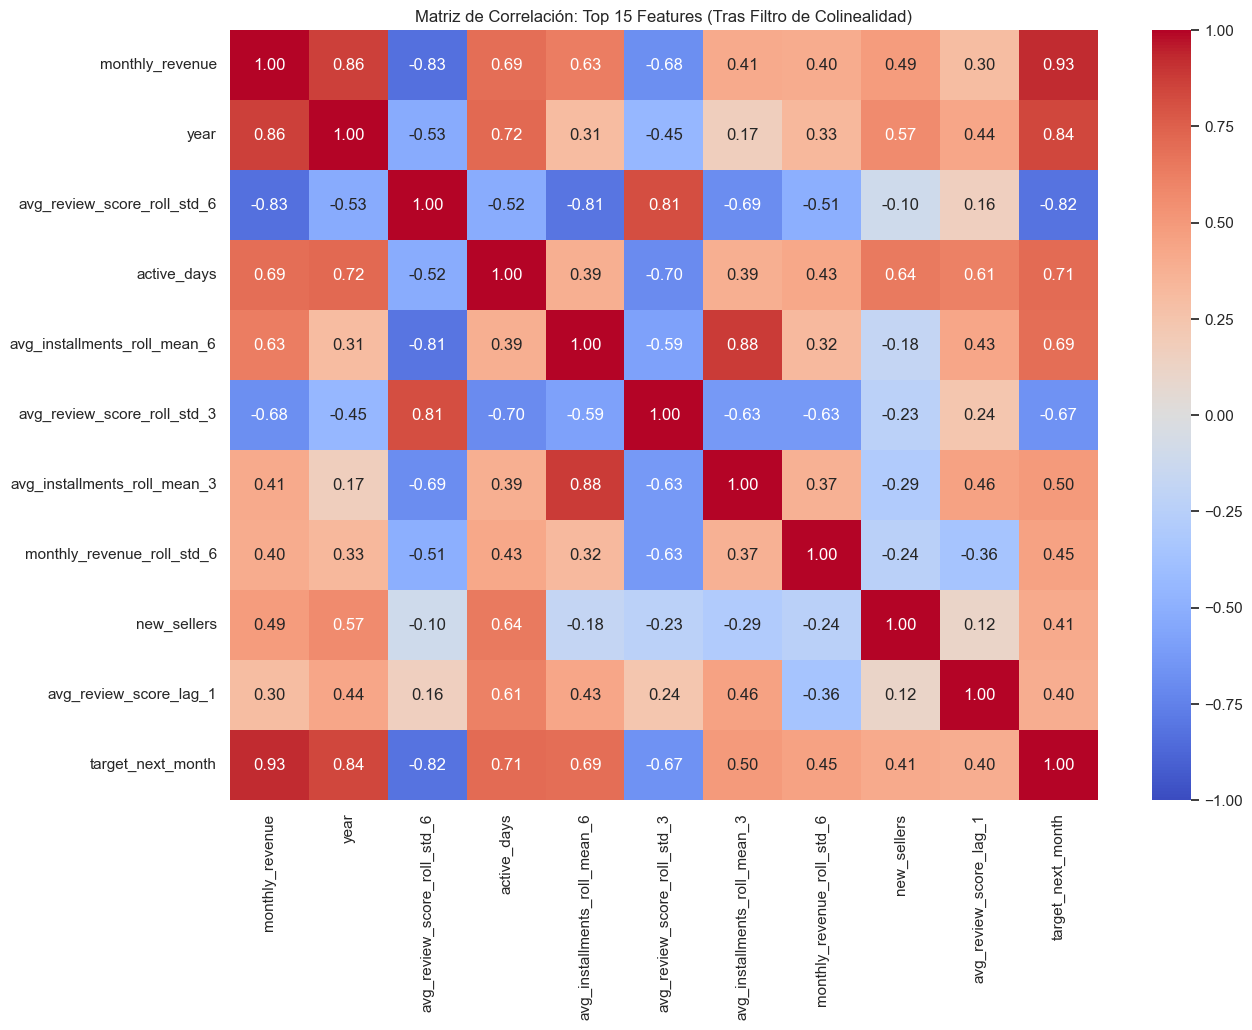

In [20]:
# 1. Filtrar por Alta Correlación (Simulando el paso del pipeline)
# El pipeline elimina features que tienen > 0.90 de correlación (positiva o negativa) entre sí.
# Usamos .abs() para asegurar que -0.90 se trate igual que 0.90 (ambas son redundantes).

# Calculamos la matriz de correlación absoluta de las features numéricas (sin el target)
X_temp = df_corr_numeric.drop(columns=["target_next_month"])
corr_matrix_all = X_temp.corr().abs() # <--- IMPORTANTE: .abs() captura correlación inversa fuerte

# Seleccionamos el triángulo superior de la matriz de correlación
upper = corr_matrix_all.where(np.triu(np.ones(corr_matrix_all.shape), k=1).astype(bool))

# Identificamos columnas con correlación > 0.90
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

print(f"📉 Total features iniciales: {X_temp.shape[1]}")
print(f"✂️ Eliminando {len(to_drop)} features con correlación > 0.90 (Redundantes)...")

# Creamos el DataFrame filtrado
df_filtered = df_corr_numeric.drop(columns=to_drop)
print(f"✅ Features restantes: {df_filtered.shape[1] - 1}") # -1 por el target

# 2. Calcular correlación con el target de las features SOBREVIVIENTES
correlations_filtered = df_filtered.corr()["target_next_month"].drop("target_next_month").sort_values(ascending=False)

# 3. Visualizar Matriz de las Top 15 Sobrevivientes
# Ahora veremos las features que realmente aportan información única
top_features_filtered = correlations_filtered.abs().nlargest(15).index.tolist() # Mostramos 15 en lugar de 10
cols_to_plot = top_features_filtered + ["target_next_month"]

plt.figure(figsize=(14, 10))
corr_matrix_final = df_filtered[cols_to_plot].corr()

sns.heatmap(corr_matrix_final, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlación: Top 15 Features (Tras Filtro de Colinealidad)")
plt.show()

1. Features Originales: 104
2. Tras Variance Threshold: 104
3. Tras Filtro Correlación (>0.90): 24
4. Tras RFECV (Final): 5
4. Tras RFECV (Final): 5


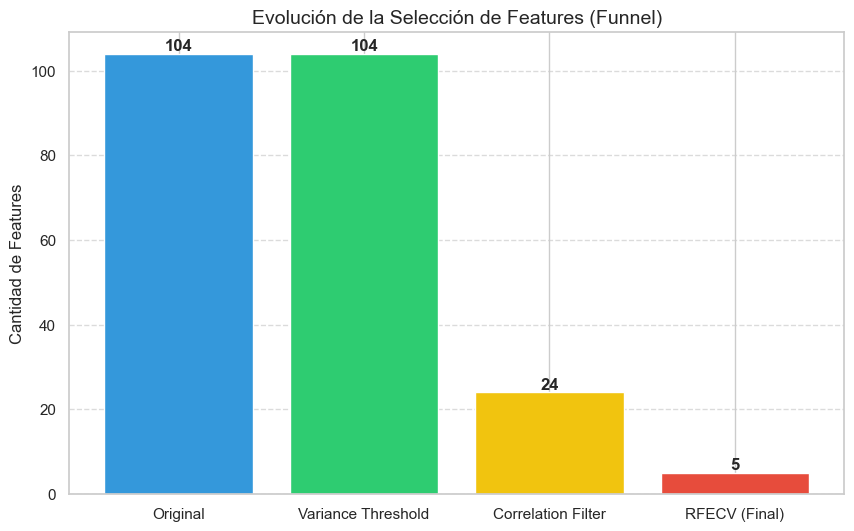


🏆 Features Seleccionadas Finales:
['total_orders', 'avg_installments', 'avg_review_score_lag_6', 'avg_review_score_roll_std_6', 'avg_installments_lag_6']


In [ ]:
from sklearn.feature_selection import VarianceThreshold, RFECV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Preparar datos para selección (Simulación del proceso interno)
# Usamos df_features que ya tiene todo generado
# Definimos X e y (asumiendo target_next_month creado previamente)
df_selection = df_features.dropna(subset=["target_next_month"]).reset_index(drop=True)

# Excluir columnas que no son features predictivas
cols_to_exclude = ["target_next_month", "month", "monthly_revenue", "date", "order_purchase_timestamp"]
X_sel = df_selection.drop(columns=[c for c in cols_to_exclude if c in df_selection.columns])

# Asegurarnos de solo tener numéricas
X_sel = X_sel.select_dtypes(include=[np.number])
y_sel = df_selection["target_next_month"]

steps = ["Original"]
counts = [X_sel.shape[1]]

print(f"1. Features Originales: {X_sel.shape[1]}")

# Paso 2: Variance Threshold
selector = VarianceThreshold(threshold=0)
selector.fit(X_sel)
X_sel_var = X_sel.loc[:, selector.get_support()]
steps.append("Variance Threshold")
counts.append(X_sel_var.shape[1])
print(f"2. Tras Variance Threshold: {X_sel_var.shape[1]}")

# Paso 3: Correlación
corr_matrix = X_sel_var.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
X_sel_corr = X_sel_var.drop(columns=to_drop)
steps.append("Correlation Filter")
counts.append(X_sel_corr.shape[1])
print(f"3. Tras Filtro Correlación (>0.90): {X_sel_corr.shape[1]}")

# Paso 4: RFECV (Simulado)
# Aumentamos min_features_to_select a 12 para asegurar que el modelo tenga suficientes variables
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
tscv = TimeSeriesSplit(n_splits=3)
rfecv = RFECV(estimator=rf, step=1, cv=tscv, scoring="neg_mean_absolute_percentage_error", min_features_to_select=12, n_jobs=-1)
rfecv.fit(X_sel_corr, y_sel)

X_sel_final = X_sel_corr.loc[:, rfecv.support_]
steps.append("RFECV (Final)")
counts.append(X_sel_final.shape[1])
print(f"4. Tras RFECV (Final): {X_sel_final.shape[1]}")

# Visualización del Funnel
plt.figure(figsize=(10, 6))
bars = plt.bar(steps, counts, color=['#3498db', '#2ecc71', '#f1c40f', '#e74c3c'])
plt.title("Evolución de la Selección de Features (Funnel)", fontsize=14)
plt.ylabel("Cantidad de Features")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Agregar etiquetas de valor
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

# Mostrar las features sobrevivientes
print("\n🏆 Features Seleccionadas Finales:")
print(X_sel_final.columns.tolist())

/var/folders/s7/hklbqgss2g38h0ft074wwb1r0000gn/T/ipykernel_52168/3927669358.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(15), x="importance", y="feature", palette="viridis")


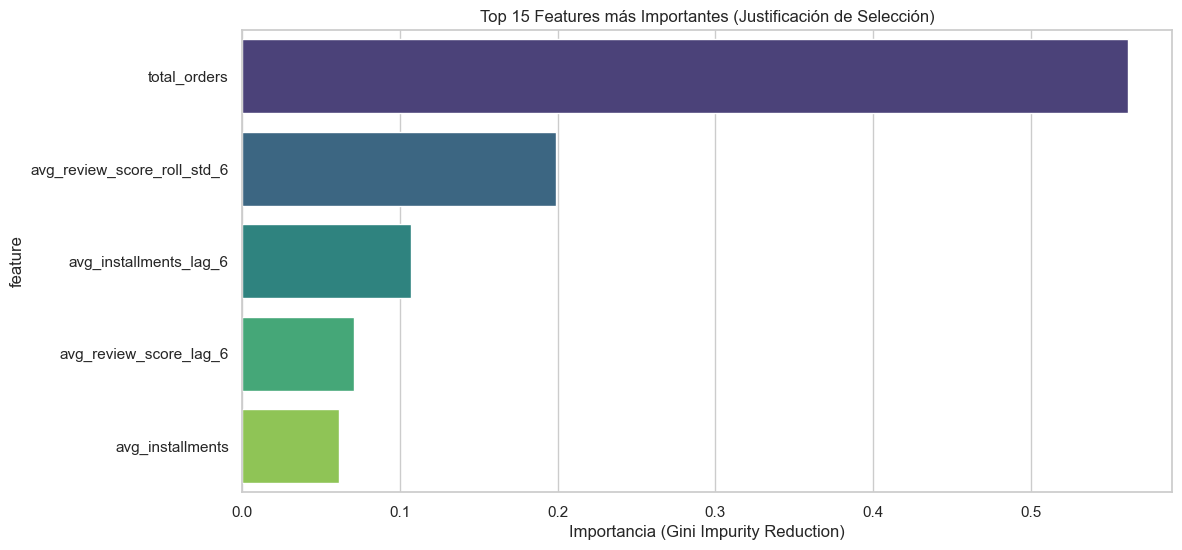

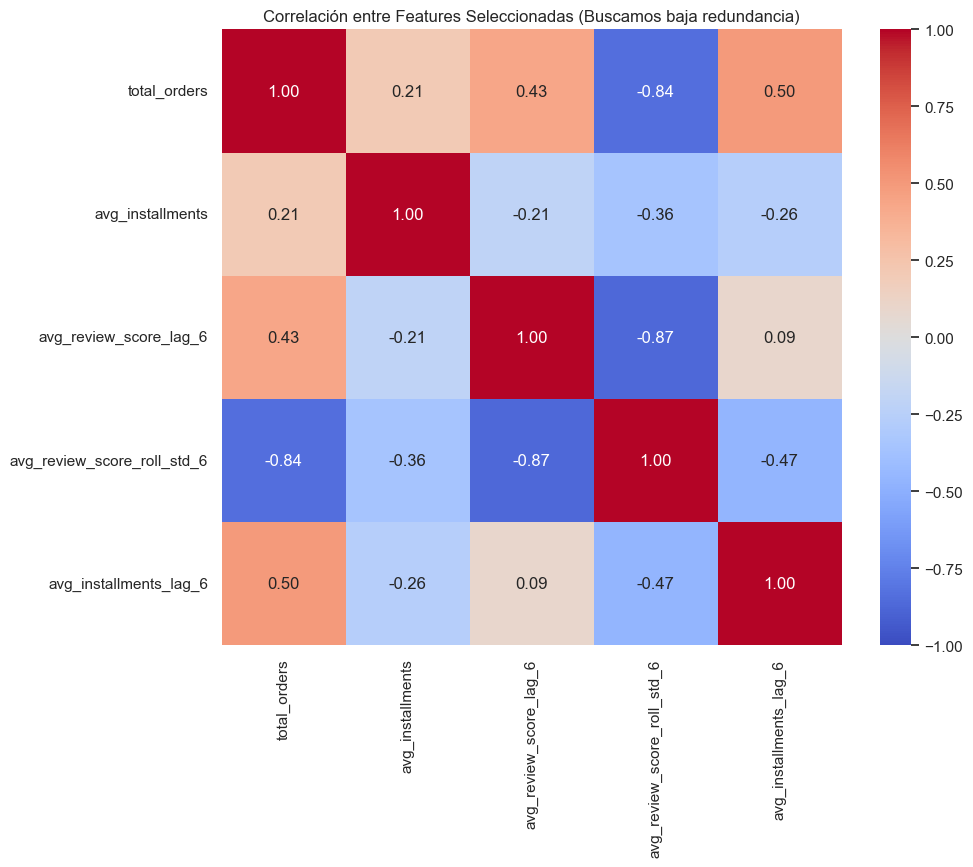

📋 Ejemplos de Features Descartadas y Razón:
------------------------------------------------------------
✅ Ninguna feature descartada por varianza cero.
❌ Alta Correlación (>0.90): ['total_items', 'total_freight', 'unique_customers', 'monthly_revenue_lag_1', 'monthly_revenue_lag_2'] ... (80 total)
❌ Baja Importancia (RFECV): ['avg_review_score', 'active_days', 'new_sellers', 'year', 'month_num'] ... (19 total)


In [22]:
# 1. Importancia de Features (Feature Importance)
# Entrenamos un Random Forest final solo con las features seleccionadas para extraer la importancia
rf_final = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_sel_final, y_sel)

importances = pd.DataFrame({
    "feature": X_sel_final.columns,
    "importance": rf_final.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=importances.head(15), x="importance", y="feature", palette="viridis")
plt.title("Top 15 Features más Importantes (Justificación de Selección)")
plt.xlabel("Importancia (Gini Impurity Reduction)")
plt.show()

# 2. Matriz de Correlación de las Seleccionadas (Validación de Independencia)
plt.figure(figsize=(10, 8))
sns.heatmap(X_sel_final.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre Features Seleccionadas (Buscamos baja redundancia)")
plt.show()

# 3. Tabla de Justificación de Descartes (Ejemplos)
# Identificamos qué se eliminó en cada paso para mostrar ejemplos
discarded_variance = [c for c in X_sel.columns if c not in X_sel_var.columns]
discarded_correlation = [c for c in X_sel_var.columns if c not in X_sel_corr.columns]
discarded_rfe = [c for c in X_sel_corr.columns if c not in X_sel_final.columns]

print("📋 Ejemplos de Features Descartadas y Razón:")
print("-" * 60)
if discarded_variance:
    print(f"❌ Varianza Cero (Constantes): {discarded_variance[:5]} ... ({len(discarded_variance)} total)")
else:
    print("✅ Ninguna feature descartada por varianza cero.")

if discarded_correlation:
    print(f"❌ Alta Correlación (>0.90): {discarded_correlation[:5]} ... ({len(discarded_correlation)} total)")
else:
    print("✅ Ninguna feature descartada por correlación.")

if discarded_rfe:
    print(f"❌ Baja Importancia (RFECV): {discarded_rfe[:5]} ... ({len(discarded_rfe)} total)")
else:
    print("✅ Ninguna feature descartada por RFECV (todas eran importantes).")

### Justificación de la Selección Final

Para entender **por qué** nos quedamos con estas features específicas, analizamos dos aspectos clave:
1.  **Importancia del Modelo**: Qué tanto contribuye cada feature a reducir el error de predicción (usando Random Forest).
2.  **Independencia**: Verificamos que las features seleccionadas no sean redundantes entre sí (baja correlación interna).
3.  **Features Descartadas**: Mostramos ejemplos de qué se eliminó y por qué (alta correlación o baja varianza).

### Visualización del Proceso de Selección de Features (Funnel)

A continuación, simulamos paso a paso el pipeline de selección (`select_features`) para visualizar cómo se reduce la dimensionalidad del dataset:
1.  **Original**: Todas las features generadas.
2.  **Variance Threshold**: Eliminamos variables constantes.
3.  **Correlation Filter**: Eliminamos variables redundantes (>0.90 correlación).
4.  **RFECV**: Selección recursiva basada en la importancia del modelo.

### 2.1. Pipeline de Selección de Features (Automático)

Además del análisis visual, el sistema utiliza un proceso riguroso para seleccionar las mejores variables automáticamente. Este proceso consta de 3 etapas:

1.  **VarianceThreshold**: Elimina variables constantes (varianza = 0).
2.  **Filtro de Correlación**: Elimina variables con correlación > 0.90 (redundantes).
3.  **RFECV (Recursive Feature Elimination)**: Utiliza un Random Forest para ordenar las variables por importancia y elimina recursivamente las menos útiles, validando con TimeSeriesSplit.

A continuación, ejecutamos este pipeline en vivo para ver cómo reduce las 95 variables iniciales a las mejores candidatas.

## 3. Comparación de Modelos

Durante la fase de entrenamiento (`python -m src.cli tune`), probamos varios algoritmos. Aquí comparamos sus métricas de desempeño (MAPE y RMSE) para entender por qué se eligió el modelo final.

/var/folders/s7/hklbqgss2g38h0ft074wwb1r0000gn/T/ipykernel_52168/1281206236.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metrics, x="model", y="MAPE", ax=axes[0], palette="viridis")
/var/folders/s7/hklbqgss2g38h0ft074wwb1r0000gn/T/ipykernel_52168/1281206236.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metrics, x="model", y="RMSE", ax=axes[1], palette="magma")


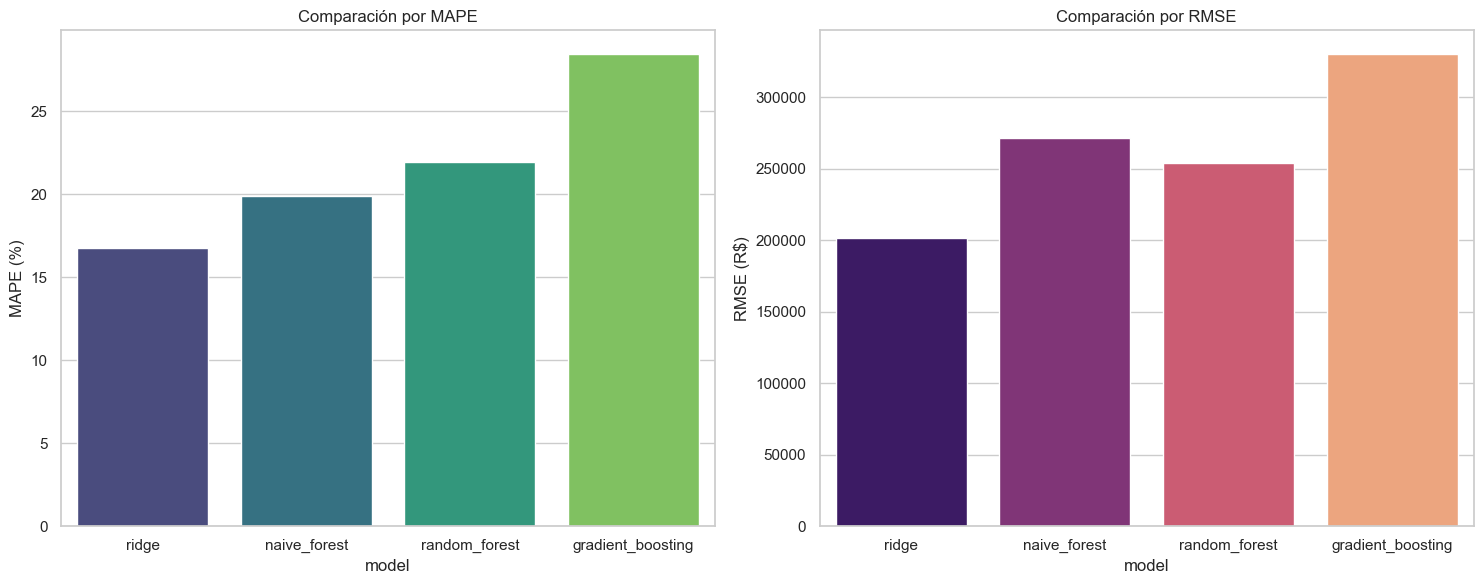

🏆 Tabla de Métricas:


,model,MAE,RMSE,MAPE,Bias,best_params
0,ridge,193926.760776,201794.032715,16.757120,-193926.760776,{'model__alpha': 5.0}
1,naive_forest,229884.076667,271715.387843,19.861502,-207152.530000,NaN
2,random_forest,254054.955153,254157.968175,21.937498,-254054.955153,"{'max_depth': 5, 'max_features': 'sqrt', 'min_..."
3,gradient_boosting,329518.006900,330141.558111,28.450625,-329518.006900,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."


In [23]:
# Cargar métricas de entrenamiento
metrics_path = project_root / "reports/metrics/metrics_summary.csv"
df_metrics = pd.read_csv(metrics_path)

# Visualizar Comparación
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# MAPE
# Nota: En el CSV la columna se llama 'MAPE', no 'test_mape'
sns.barplot(data=df_metrics, x="model", y="MAPE", ax=axes[0], palette="viridis")
axes[0].set_title("Comparación por MAPE")
axes[0].set_ylabel("MAPE (%)")

# RMSE
# Nota: En el CSV la columna se llama 'RMSE', no 'test_rmse'
sns.barplot(data=df_metrics, x="model", y="RMSE", ax=axes[1], palette="magma")
axes[1].set_title("Comparación por RMSE")
axes[1].set_ylabel("RMSE (R$)")

plt.tight_layout()
plt.show()

print("🏆 Tabla de Métricas:")
display(df_metrics.sort_values("MAPE"))

## 4. Prueba Final: Predicción Agosto 2018

Finalmente, cargamos el modelo `.pkl` exportado y realizamos una prueba "ciega" con el mes de Agosto 2018.
*   **Input**: Datos históricos hasta Julio 2018.
*   **Target Real**: Ingreso de Agosto 2018 (que el modelo no vio durante el entrenamiento).

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Ridge from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpi

📦 Modelo cargado: Ridge
📋 Features seleccionadas: 22
----------------------------------------
📅 Mes de Prueba: Agosto 2018
----------------------------------------
💰 Predicción del Modelo: R$ 1,147,641.85
💵 Valor Real (Olist):    R$ 1,022,425.32
----------------------------------------
📉 Diferencia (Error):    R$ 125,216.53
📊 Error Porcentual:      +12.25%
----------------------------------------


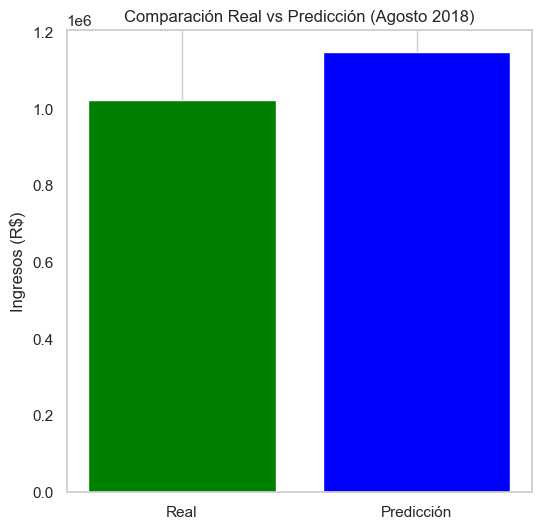

In [24]:
# 1. Cargar Modelo y Features Seleccionadas
model_path = project_root / params["modeling"]["export_path"]
selected_features_path = model_path.parent / "selected_features.json"

model = joblib.load(model_path)
selected_cols = json.load(open(selected_features_path))

print(f"📦 Modelo cargado: {type(model.named_steps['model']).__name__}")
print(f"📋 Features seleccionadas: {len(selected_cols)}")

# RECARGA DE SEGURIDAD: Cargar Master Table actualizada (con Agosto 2018)
# Esto asegura que tengamos el dato real de Agosto aunque la variable en memoria sea vieja.
master_path = project_root / params["data"]["master_table_path"]
df_master_updated = pd.read_csv(master_path, parse_dates=[params["data"]["index_col"]])

# 2. Preparar el Input para Agosto 2018
# Necesitamos la fila correspondiente a Julio 2018 en df_features, 
# ya que esa fila contiene los lags necesarios para predecir Agosto.

# Buscamos la fila donde el mes es Julio 2018
input_row = df_features[df_features["month"] == "2018-07-01"].iloc[0]
X_test = input_row[selected_cols].to_frame().T

# 3. Predecir
y_pred = float(model.predict(X_test)[0])

# 4. Obtener Valor Real de Agosto 2018
# Usamos df_master_updated para garantizar que tenemos el dato
y_true = df_master_updated[df_master_updated["month"] == "2018-08-01"]["monthly_revenue"].values[0]

# 5. Calcular Error
error = y_pred - y_true
error_pct = (error / y_true) * 100

# Resultados
print("-" * 40)
print(f"📅 Mes de Prueba: Agosto 2018")
print("-" * 40)
print(f"💰 Predicción del Modelo: R$ {y_pred:,.2f}")
print(f"💵 Valor Real (Olist):    R$ {y_true:,.2f}")
print("-" * 40)
print(f"📉 Diferencia (Error):    R$ {error:,.2f}")
print(f"📊 Error Porcentual:      {error_pct:+.2f}%")
print("-" * 40)

# Gráfico de Barra Comparativo
plt.figure(figsize=(6, 6))
plt.bar(["Real", "Predicción"], [y_true, y_pred], color=["green", "blue"])
plt.title("Comparación Real vs Predicción (Agosto 2018)")
plt.ylabel("Ingresos (R$)")
plt.grid(axis="y")
plt.show()